# 📊 Comprehensive Fitting Pipeline (860 cm⁻¹)

This notebook is organized to compare three different fitting methods on the 860 cm⁻¹ wavenumber data:
1. **Complex Hankel Transform (CHT)**: The $k$-space method from the 2015 Nature Materials paper.
2. **Real Space Hankel**: Fitting the spatial amplitude directly using the Hankel model.
3. **Real Space $1/\sqrt{x}$**: Fitting the spatial amplitude directly using an inverse square-root envelope.

All results are extracted and automatically logged into `data/fitting_results_comparison.csv`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import scipy.special as sp
import sys
sys.path.append('.')
import nanoftir_Shizhe as nanoftir
import importlib
importlib.reload(nanoftir)
%matplotlib widget
# 🎨 APS Plotting Style Configuration
plt.rcParams.update({
    'font.size': 12, 'font.family': 'Arial',
    'axes.linewidth': 1.5, 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True,
    'ytick.right': True
})

## 1. Load Data & Boundary Truncation
Based on your observation, we force the boundary at **0.35 μm** and slice the data from there.

In [16]:
filepath = 'data/GMG3_graphen3x1_linecuts.csv'
df = pd.read_csv(filepath, comment='#')
x_raw = df['pixel_index'].values * 0.015
target_wn = '860_cm⁻¹'
y_raw = df[target_wn].values

# Force boundary at ~0.35 um
idx_boundary = np.argmin(np.abs(x_raw - 0.35))
x_boundary = x_raw[idx_boundary]
x_mat = x_raw[idx_boundary:] - x_boundary
y_mat = y_raw[idx_boundary:]

# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
sig_f = y_mat - y_bg

L_cutoff = 0.9
mask_fit = x_mat <= L_cutoff
x_f = x_mat[mask_fit]
sig_f = sig_f[mask_fit]

print(f"Boundary used: {x_boundary:.3f} μm (Index: {idx_boundary})")

Boundary used: 0.345 μm (Index: 23)


## 2. Fit 1: Complex Hankel Transform (CHT)
Here is the CHT fit. You can adjust the parameters below.
- `lam0_guess_um`: Your initial guess for the wavelength (e.g. 0.400).
- `k_fit_range`: The momentum range to fit the peak. You can try `(2, 30)` or `(4, 25)` depending on where the peak is.
- `L_cutoff`: The distance cutoff for the Hankel transform integral.

CHT Result: Wavelength = 454.5 nm, Damping = 6.9


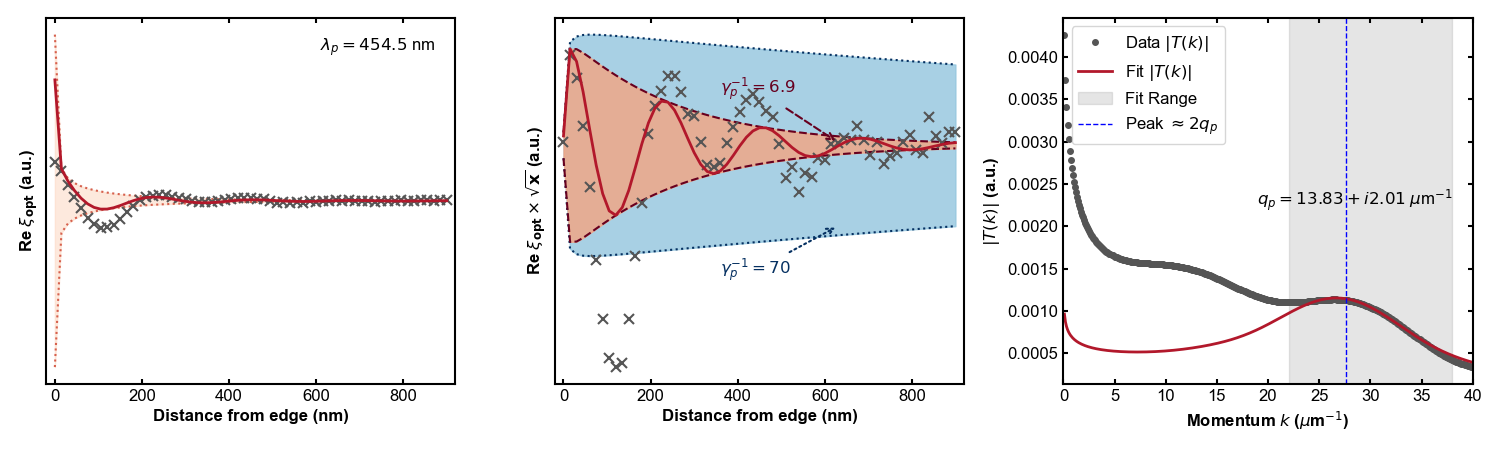

In [17]:
# === Tunable Parameters for CHT ===
lam0_guess_um = 0.400
L_cutoff = 0.9
k_fit_range = (22, 38)
# ==================================

q_re_guess = 2 * np.pi / lam0_guess_um
p0_guess = [np.nanmax(np.abs(sig_f)), q_re_guess, 0.5, 0.0]

fit_params_cht, k_arr, T_data, T_mod, mod_sig_cplx = nanoftir.fit_cht_peaks(
    x_f, sig_f, L=L_cutoff, k_fit_range=k_fit_range, p0=p0_guess, k_plot_range=(0.1, 40)
)

A_fit, q_re_fit, q_im_fit, phase_fit = fit_params_cht
lam_cht = (2 * np.pi / q_re_fit) * 1000
damping_cht = q_re_fit / q_im_fit
q_p = q_re_fit + 1j * q_im_fit

print(f"CHT Result: Wavelength = {lam_cht:.1f} nm, Damping = {damping_cht:.1f}")

# Reconstruct the real-space model
mod_sig_fit = np.real(mod_sig_cplx)

# Envelope calculation
x_safe = np.maximum(x_f, 1e-5)
envelope = A_fit * np.abs(sp.hankel1(0, 2 * q_p * x_safe))

# ==========================================
# 📊 Plotting in Paper Style + k-space
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=100)

c_data = '#555555'  
c_fit = '#b2182b'   
c_env_a = '#fddbc7' 
c_env_b_blue = '#92c5de' 
c_env_b_red = '#f4a582'  

# Panel (a)
ax = axes[0]
x_nm = x_f * 1000
ax.fill_between(x_nm, envelope, -envelope, color=c_env_a, alpha=0.6)
ax.plot(x_nm, envelope, color='#d6604d', linestyle=':', lw=1.5)
ax.plot(x_nm, -envelope, color='#d6604d', linestyle=':', lw=1.5)
ax.plot(x_nm, sig_f, marker='x', markersize=7, markeredgewidth=1.5, linestyle='None', color=c_data, label='Data')
ax.plot(x_nm, mod_sig_fit, color=c_fit, lw=2, label='Fit')
ax.set_xlabel('Distance from edge (nm)', fontweight='bold')
ax.set_ylabel(r'Re $\xi_{\mathbf{opt}}$ (a.u.)', fontweight='bold')
ax.set_xlim(-20, L_cutoff * 1000 + 20)
ax.set_yticks([])
txt_a = rf"$\lambda_p = {lam_cht:.1f}$ nm"
ax.text(0.95, 0.95, txt_a, transform=ax.transAxes, fontsize=12, va='top', ha='right')

# Panel (b)
ax = axes[1]
sqrt_x = np.sqrt(x_safe)
sig_fit_sqrt = sig_f * sqrt_x
mod_sig_fit_sqrt = mod_sig_fit * sqrt_x
envelope_sqrt = envelope * sqrt_x

q_im_ideal = q_re_fit / 70.0
q_p_ideal = q_re_fit + 1j * q_im_ideal
envelope_ideal = A_fit * np.abs(sp.hankel1(0, 2 * q_p_ideal * x_safe))
envelope_sqrt_ideal = envelope_ideal * sqrt_x

ax.fill_between(x_nm, envelope_sqrt_ideal, -envelope_sqrt_ideal, color=c_env_b_blue, alpha=0.8)
ax.fill_between(x_nm, envelope_sqrt, -envelope_sqrt, color=c_env_b_red, alpha=0.8)
ax.plot(x_nm, envelope_sqrt_ideal, color='#053061', linestyle=':', lw=1.5)
ax.plot(x_nm, -envelope_sqrt_ideal, color='#053061', linestyle=':', lw=1.5)
ax.plot(x_nm, envelope_sqrt, color='#67001f', linestyle='--', lw=1.5)
ax.plot(x_nm, -envelope_sqrt, color='#67001f', linestyle='--', lw=1.5)
ax.plot(x_nm, sig_fit_sqrt, marker='x', markersize=7, markeredgewidth=1.5, linestyle='None', color=c_data)
ax.plot(x_nm, mod_sig_fit_sqrt, color=c_fit, lw=2)

ax.set_xlabel('Distance from edge (nm)', fontweight='bold')
ax.set_ylabel(r'Re $\xi_{\mathbf{opt}} \times \sqrt{\mathbf{x}}$ (a.u.)', fontweight='bold')
ax.set_xlim(-20, L_cutoff * 1000 + 20)
ax.set_yticks([])

max_env = np.max(envelope_sqrt)
ax.annotate(rf"$\gamma_p^{{-1}} = {damping_cht:.1f}$", 
            xy=(x_nm[-1]*0.7, envelope_sqrt[-1]*1.0),
            xytext=(x_nm[-1]*0.4, envelope_sqrt[-1]*1.0 + 0.5 * max_env),
            color='#67001f', fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle="->", color='#67001f', lw=1.5, linestyle='--'))

ax.annotate(rf"$\gamma_p^{{-1}} = 70$", 
            xy=(x_nm[-1]*0.7, -envelope_sqrt_ideal[-1]*1.0),
            xytext=(x_nm[-1]*0.4, -envelope_sqrt_ideal[-1]*1.0 - 0.5 * max_env),
            color='#053061', fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle="->", color='#053061', lw=1.5, linestyle=':'))

# Panel (c): k-space
ax = axes[2]
ax.plot(k_arr, np.abs(T_data), 'o', color=c_data, markersize=4, label='Data $|T(k)|$')
ax.plot(k_arr, np.abs(T_mod), '-', color=c_fit, lw=2, label='Fit $|T(k)|$')
ax.axvspan(k_fit_range[0], k_fit_range[1], color='gray', alpha=0.2, label='Fit Range')

# Peak position in k-space is approx 2 * Re(q_p)
k_peak = 2 * q_re_fit
ax.axvline(k_peak, color='blue', linestyle='--', lw=1, label=rf'Peak $\approx 2q_p$')

ax.set_xlabel(r'Momentum $k$ ($\mu$m$^{-1}$)', fontweight='bold')
ax.set_ylabel(r'$|T(k)|$ (a.u.)', fontweight='bold')
ax.set_xlim(0, 40)
ax.legend()
txt_c = rf"$q_p = {q_re_fit:.2f} + i{q_im_fit:.2f}$ $\mu$m$^{{-1}}$"
ax.text(0.95, 0.5, txt_c, transform=ax.transAxes, fontsize=12, va='center', ha='right')

plt.tight_layout()

## 3. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)
Using your `compare_cavity_models` wrapper. I have updated `nanoftir_Shizhe.py` to natively support `edges='single'`!
This means we no longer need to hack the boundary to infinity. We just pass `edges='single'` and it correctly fits only the left boundary launched wave.

hankel    q=1.25e+05 cm^-1  lambda=0.504 um  q_imag=2.651 um^-1 (2.65e+04 cm^-1)  a=None  rmse=0.06651  aic=-325.88
1/sqrtx   q=1.36e+05 cm^-1  lambda=0.462 um  alpha_env=3.974 um^-1 (3.97e+04 cm^-1)  a=None  rmse=0.075  aic=-311.23


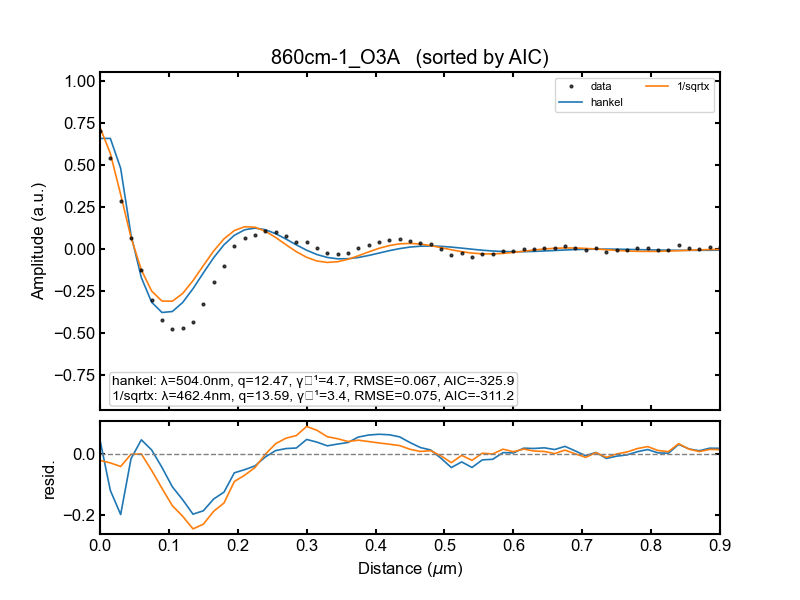

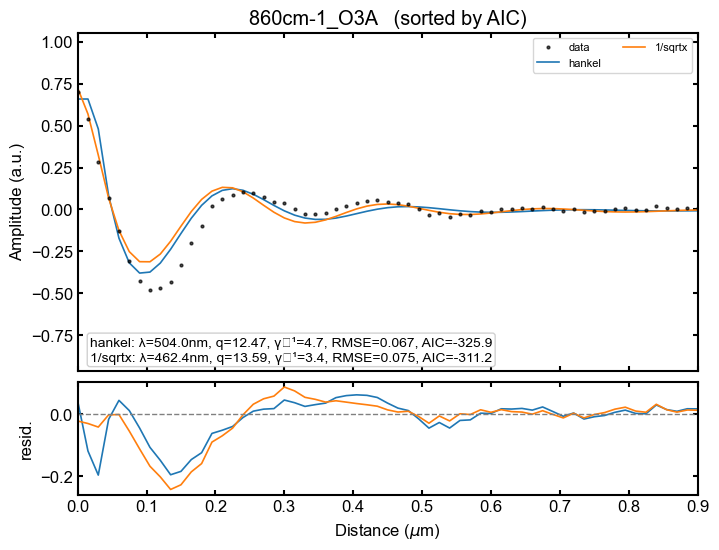

In [30]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    '860cm-1_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.0, 1.2)   # 🌟 BUG FIXED: x_f already starts at 0, so left edge must be 0!
win_size = 3            # Window size for smoothing before peak-finding (larger = smoother)
prominence = 0.01       # Prominence for peak finding
lam0_guess_um = 0.4200   # Initial guess for wavelength
# ==============================================

# Call the wrapper with natively supported single-edge mode
outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, '860cm-1_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    xlim=(x_f.min(), x_f.max()),
    figsize=(8, 6)
)
plt.show()
fig
# Display the figure in the notebook

## 4. Standard FFT Analysis (Comparison)
Let's compare the CHT momentum-space peak with a standard 1D FFT using your `plot_channel_fft` function.

Could not load phaselp automatically: [Errno 2] No such file or directory: 'data/NearField/lineprofile/D=151nm_W=NA_100Au_Phase_lineprofile.txt'
Running standard FFT comparison...


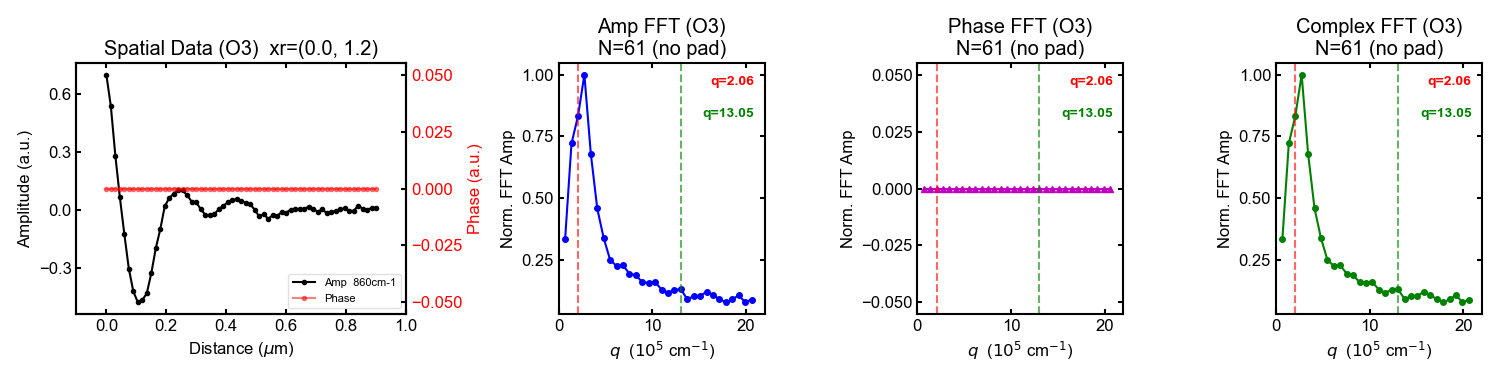

In [29]:
# === Standard 1D FFT Analysis ===
# Load the phase data to enable complex FFT
import pandas as pd
import numpy as np

phaselp_path = 'data/NearField/lineprofile/D=151nm_W=NA_100Au_Phase_lineprofile.txt'
try:
    if 'phaselp' not in locals():
        phaselp = pd.read_csv(phaselp_path, delimiter='\t')
        phaselp.columns = phaselp.columns.str.strip()
except Exception as e:
    print(f"Could not load phaselp automatically: {e}")

try:
    print("Running standard FFT comparison...")
    x_dist = amplp['distance_um']
    amp_raw = amplp['860cm-1_O3A']
    
    if 'phaselp' in locals() and '860cm-1_O3P' in phaselp.columns:
        phase_raw = phaselp['860cm-1_O3P']
        print("Using real Phase data for complex FFT.")
    else:
        phase_raw = pd.Series(np.zeros_like(amp_raw))
        print("WARNING: '860cm-1_O3P' not found in phaselp. Using dummy phase (0).")
    
    # 🌟 q_guess is exposed here! Adjust [5, 30] to search for peaks in different k regions.
    nanoftir.plot_channel_fft(
        x_dist, amp_raw, phase_raw, 
        label='O3', wn='860cm-1',
        xr=(0.0, 1.2), q_range=(0, 22),
        window='boxcar', pad_factor=1.0,
        q_guess=[2, 18] 
    )
except Exception as e:
    print(f"Error running FFT: {e}")
